Лаб.работа №6.(encoders)

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(42)
torch.manual_seed(42)

Создание признакового пространства.

In [57]:
n_normal = 10000
n_fraud = 200
print(f"\nПараметры генерации:")
print(f"  - Обычные транзакции: {n_normal}")
print(f"  - Мошеннические транзакции: {n_fraud}")
print(f"  - Дисбаланс: {n_normal/n_fraud:.1f}:1")
n_features = 30
normal_data = np.random.normal(loc=0, scale=1, size=(n_normal, n_features))
for i in range(n_features):
    for j in range(i+1, n_features):
        if np.random.random() < 0.3:
            correlation = np.random.uniform(0.3, 0.7)
            normal_data[:, j] += correlation * normal_data[:, i]
print(f"\nОбычные транзакции сгенерированы: {normal_data.shape}")
print(f"  - Среднее: {normal_data.mean():.4f}")
print(f"  - Стандартное отклонение: {normal_data.std():.4f}")


Параметры генерации:
  - Обычные транзакции: 10000
  - Мошеннические транзакции: 200
  - Дисбаланс: 50.0:1

Обычные транзакции сгенерированы: (10000, 30)
  - Среднее: 0.0737
  - Стандартное отклонение: 7.3642


Генерация мошеннических транзакций (аномалий).

In [58]:
fraud_data = []
for i in range(n_fraud):
    transaction = np.random.normal(loc=0, scale=1, size=n_features)
    n_outliers = np.random.randint(2, 6)
    outlier_indices = np.random.choice(n_features, n_outliers, replace=False)
    for idx in outlier_indices:
        outlier_strength = np.random.choice([-1, 1]) * np.random.uniform(3, 8)
        transaction[idx] += outlier_strength
    fraud_data.append(transaction)
fraud_data = np.array(fraud_data)
print(f"\nМошеннические транзакции сгенерированы: {fraud_data.shape}")
print(f"  - Среднее: {fraud_data.mean():.4f}")
print(f"  - Стандартное отклонение: {fraud_data.std():.4f}")


Мошеннические транзакции сгенерированы: (200, 30)
  - Среднее: 0.0429
  - Стандартное отклонение: 2.2081


Объединение данных и создание датафрейма.


Итоговый датасет:
  - Форма: (10200, 31)
  - Распределение классов:
Class
0.0    10000
1.0      200
Name: count, dtype: int64
  - Процент мошенничества: 1.96%


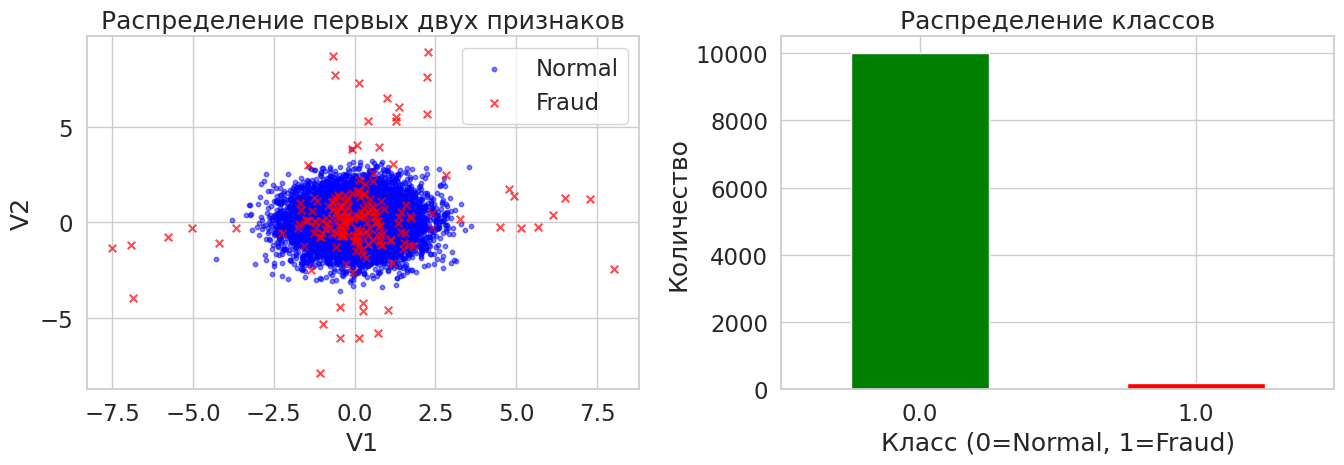

In [59]:
X = np.vstack([normal_data, fraud_data])
y = np.hstack([np.zeros(n_normal), np.ones(n_fraud)])
feature_names = [f'V{i+1}' for i in range(n_features)]
df = pd.DataFrame(X, columns=feature_names)
df['Class'] = y
print(f"\nИтоговый датасет:")
print(f"  - Форма: {df.shape}")
print(f"  - Распределение классов:")
print(df['Class'].value_counts())
print(f"  - Процент мошенничества: {df['Class'].mean()*100:.2f}%")
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.scatter(df[df['Class']==0]['V1'], df[df['Class']==0]['V2'],
            alpha=0.5, s=10, label='Normal', c='blue')
plt.scatter(df[df['Class']==1]['V1'], df[df['Class']==1]['V2'],
            alpha=0.7, s=30, label='Fraud', c='red', marker='x')
plt.xlabel('V1')
plt.ylabel('V2')
plt.title('Распределение первых двух признаков')
plt.legend()
plt.subplot(1, 2, 2)
df['Class'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Распределение классов')
plt.xlabel('Класс (0=Normal, 1=Fraud)')
plt.ylabel('Количество')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Нормализация данных.

In [60]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nРазделение данных:")
print(f"  - Обучающая выборка: {X_train.shape}")
print(f"  - Тестовая выборка: {X_test.shape}")
print(f"  - Распределение в обучающей: {np.bincount(y_train.astype(int))}")
print(f"  - Распределение в тестовой: {np.bincount(y_test.astype(int))}")
X_train_normal = X_train[y_train == 0]
print(f"\nДанные для обучения автоэнкодера (только нормальные): {X_train_normal.shape}")


Разделение данных:
  - Обучающая выборка: (8160, 30)
  - Тестовая выборка: (2040, 30)
  - Распределение в обучающей: [8000  160]
  - Распределение в тестовой: [2000   40]

Данные для обучения автоэнкодера (только нормальные): (8000, 30)


Создание автоэнкодера.

In [61]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim, encoding_dim=10):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, input_dim // 2),
            nn.ReLU(),
            nn.Linear(input_dim // 2, input_dim // 4),
            nn.ReLU(),
            nn.Linear(input_dim // 4, encoding_dim),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(encoding_dim, input_dim // 4),
            nn.ReLU(),
            nn.Linear(input_dim // 4, input_dim // 2),
            nn.ReLU(),
            nn.Linear(input_dim // 2, input_dim),
            nn.Sigmoid()
        )
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded
input_dim = X_train.shape[1]
encoding_dim = 10
model = Autoencoder(input_dim, encoding_dim)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
print(f"\nАрхитектура автоэнкодера:")
print(f"  - Входная размерность: {input_dim}")
print(f"  - Размерность скрытого слоя: {encoding_dim}")
print(f"  - Общее количество параметров: {sum(p.numel() for p in model.parameters())}")


Архитектура автоэнкодера:
  - Входная размерность: 30
  - Размерность скрытого слоя: 10
  - Общее количество параметров: 1334


Обучение модели.


Начало обучения...
--------------------------------------------------
Эпоха [20/100], Потери: 0.650368
Эпоха [40/100], Потери: 0.641831
Эпоха [60/100], Потери: 0.636313
Эпоха [80/100], Потери: 0.634195
Эпоха [100/100], Потери: 0.626186
--------------------------------------------------
Обучение завершено!


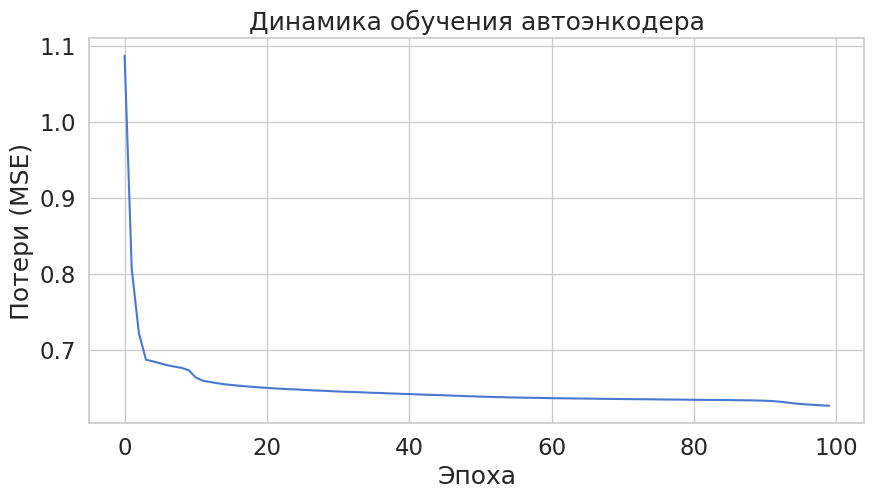

In [62]:
train_dataset = TensorDataset(torch.FloatTensor(X_train_normal))
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

num_epochs = 100
train_losses = []

print("\nНачало обучения...")
print("-" * 50)

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0

    for batch in train_loader:
        data = batch[0]

        output = model(data)
        loss = criterion(output, data)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    if (epoch + 1) % 20 == 0:
        print(f"Эпоха [{epoch+1}/{num_epochs}], Потери: {avg_loss:.6f}")

print("-" * 50)
print("Обучение завершено!")
plt.figure(figsize=(10, 5))
plt.plot(train_losses)
plt.title('Динамика обучения автоэнкодера')
plt.xlabel('Эпоха')
plt.ylabel('Потери (MSE)')
plt.grid(True)
plt.show()

Оценка на тестовых данных.

In [63]:
model.eval()
test_dataset = TensorDataset(torch.FloatTensor(X_test))
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

reconstruction_errors = []

with torch.no_grad():
    for batch in test_loader:
        data = batch[0]
        output = model(data)
        error = torch.mean((output - data) ** 2).item()
        reconstruction_errors.append(error)

results_df = pd.DataFrame({
    'reconstruction_error': reconstruction_errors,
    'true_class': y_test
})

print(f"\nСтатистика ошибок реконструкции:")
print(results_df.groupby('true_class')['reconstruction_error'].describe())


Статистика ошибок реконструкции:
             count      mean       std       min       25%       50%  \
true_class                                                             
0.0         2000.0  0.656350  0.797475  0.058034  0.217941  0.357552   
1.0           40.0  1.523146  0.992323  0.298367  0.751033  1.221303   

                 75%       max  
true_class                      
0.0         0.727908  7.041543  
1.0         2.022593  4.476470  


Визуализация ошибок реконструкции.

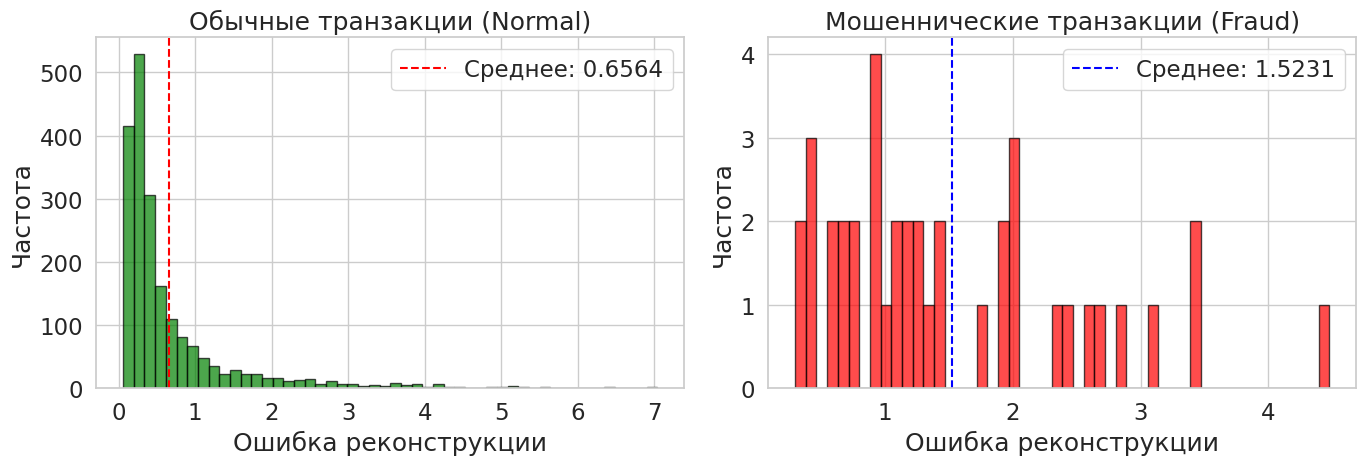

<Figure size 800x600 with 0 Axes>

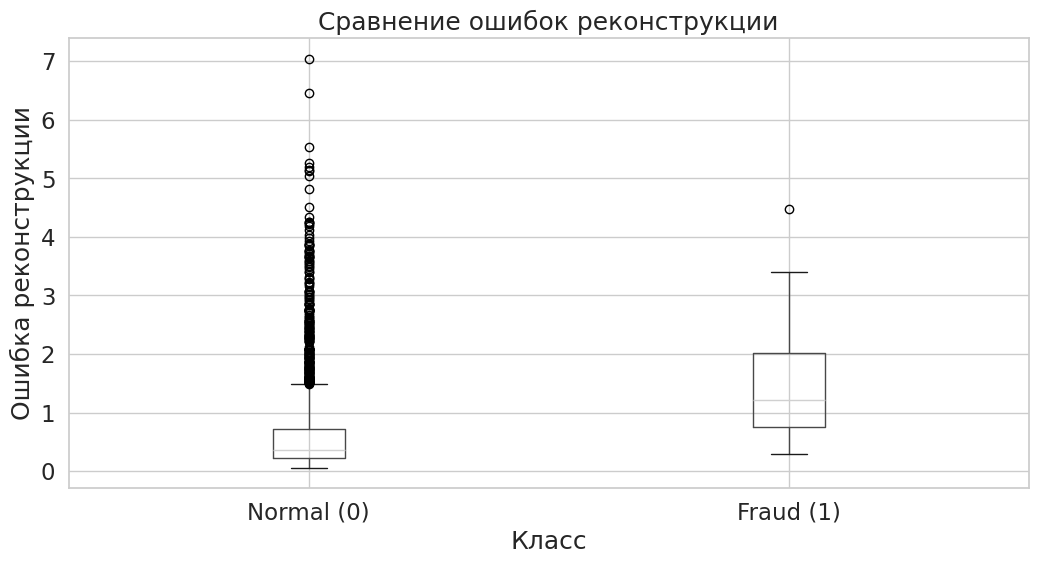

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

normal_errors = results_df[results_df['true_class'] == 0]['reconstruction_error']
axes[0].hist(normal_errors, bins=50, alpha=0.7, color='green', edgecolor='black')
axes[0].set_title('Обычные транзакции (Normal)')
axes[0].set_xlabel('Ошибка реконструкции')
axes[0].set_ylabel('Частота')
axes[0].axvline(normal_errors.mean(), color='red', linestyle='--', label=f'Среднее: {normal_errors.mean():.4f}')
axes[0].legend()

fraud_errors = results_df[results_df['true_class'] == 1]['reconstruction_error']
axes[1].hist(fraud_errors, bins=50, alpha=0.7, color='red', edgecolor='black')
axes[1].set_title('Мошеннические транзакции (Fraud)')
axes[1].set_xlabel('Ошибка реконструкции')
axes[1].set_ylabel('Частота')
axes[1].axvline(fraud_errors.mean(), color='blue', linestyle='--', label=f'Среднее: {fraud_errors.mean():.4f}')
axes[1].legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
results_df.boxplot(column='reconstruction_error', by='true_class')
plt.title('Сравнение ошибок реконструкции')
plt.suptitle('')
plt.xlabel('Класс')
plt.ylabel('Ошибка реконструкции')
plt.xticks([1, 2], ['Normal (0)', 'Fraud (1)'])
plt.show()

Выбор порога и классификация.


Выбранный порог: 2.380570


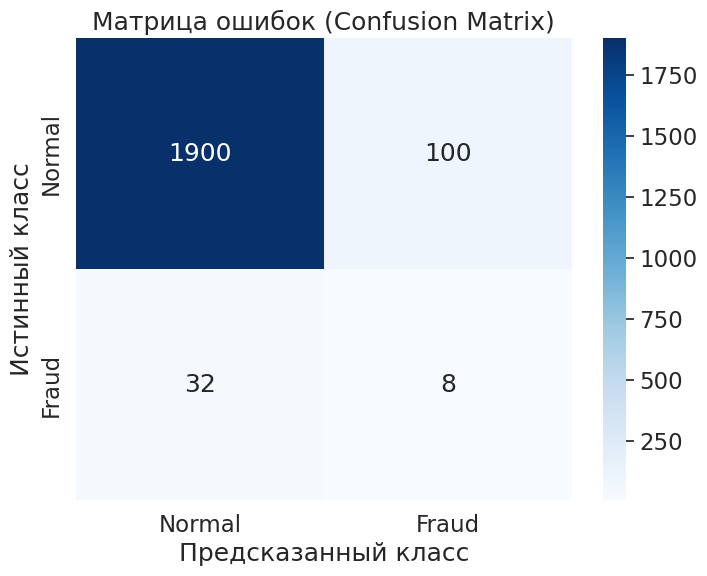


ОТЧЕТ О КЛАССИФИКАЦИИ
              precision    recall  f1-score   support

  Normal (0)       0.98      0.95      0.97      2000
   Fraud (1)       0.07      0.20      0.11        40

    accuracy                           0.94      2040
   macro avg       0.53      0.57      0.54      2040
weighted avg       0.97      0.94      0.95      2040



In [65]:
threshold = np.percentile(normal_errors, 95)
print(f"\nВыбранный порог: {threshold:.6f}")

y_pred = (results_df['reconstruction_error'] > threshold).astype(int)

from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

cm = confusion_matrix(results_df['true_class'], y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
plt.title('Матрица ошибок (Confusion Matrix)')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.show()

print("\n" + "="*60)
print("ОТЧЕТ О КЛАССИФИКАЦИИ")
print("="*60)
print(classification_report(results_df['true_class'], y_pred, target_names=['Normal (0)', 'Fraud (1)']))

ROC-кривая и AUC.

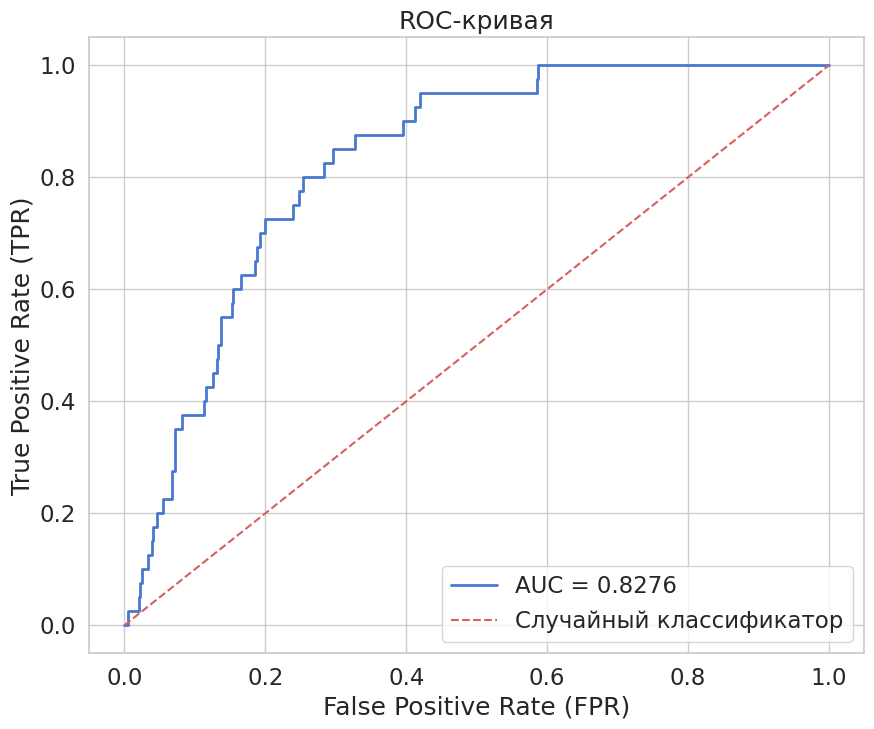

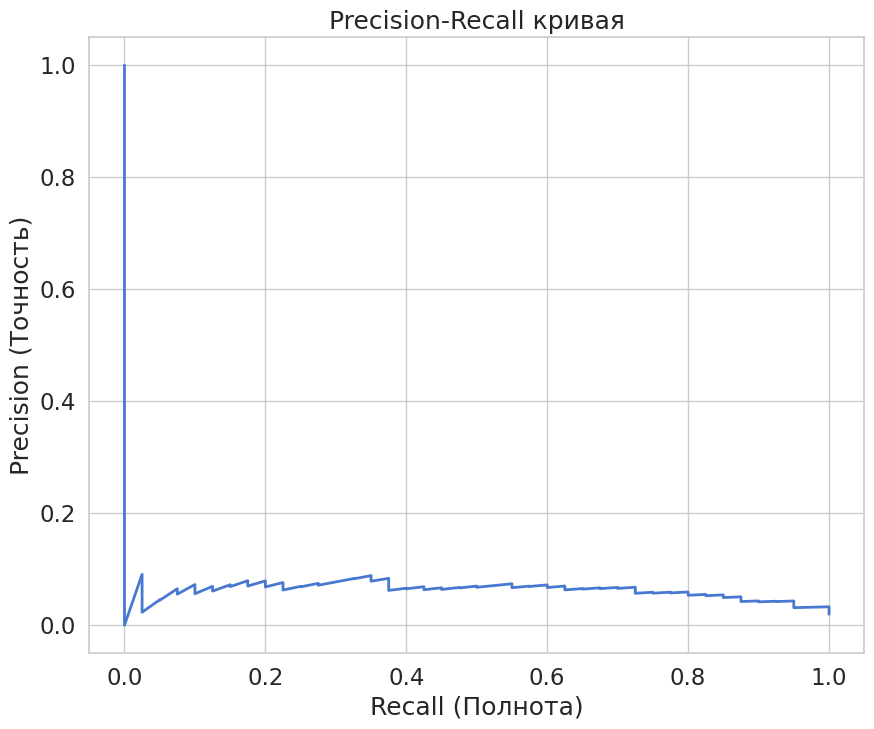

In [66]:
fpr, tpr, thresholds_roc = roc_curve(results_df['true_class'], results_df['reconstruction_error'])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}', linewidth=2)
plt.plot([0, 1], [0, 1], 'r--', label='Случайный классификатор')
plt.title('ROC-кривая')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

from sklearn.metrics import precision_recall_curve

precision, recall, thresholds_pr = precision_recall_curve(results_df['true_class'], results_df['reconstruction_error'])

plt.figure(figsize=(10, 8))
plt.plot(recall, precision, 'b-', linewidth=2)
plt.title('Precision-Recall кривая')
plt.xlabel('Recall (Полнота)')
plt.ylabel('Precision (Точность)')
plt.grid(True)
plt.show()

Визуализация предсказаний.

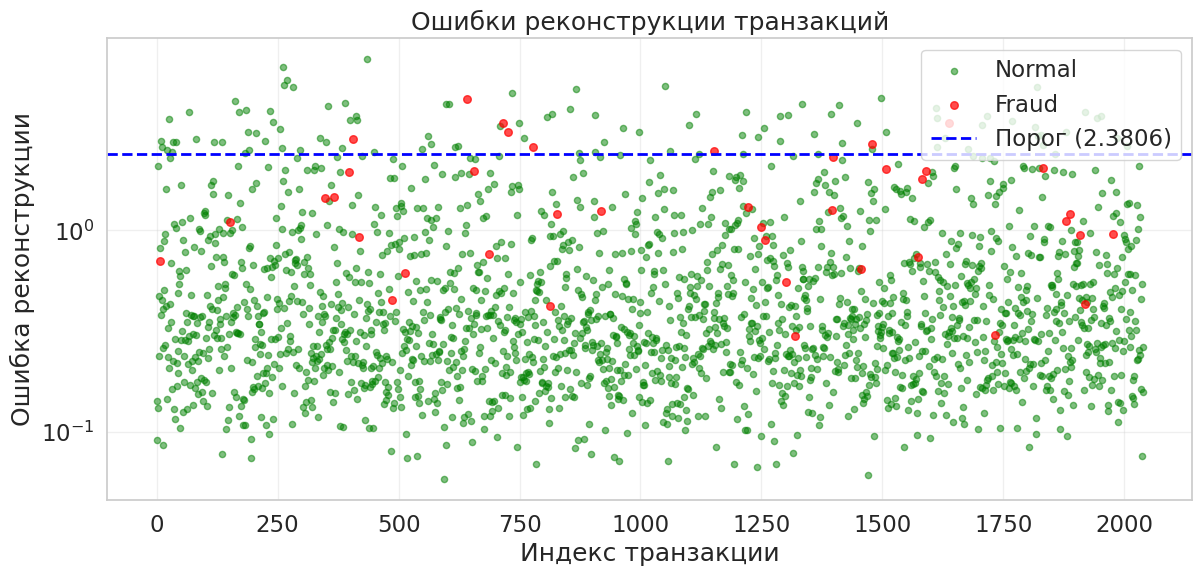

In [67]:
plt.figure(figsize=(14, 6))

normal_data_points = results_df[results_df['true_class'] == 0]
fraud_data_points = results_df[results_df['true_class'] == 1]

plt.scatter(normal_data_points.index, normal_data_points['reconstruction_error'],
            c='green', alpha=0.5, label='Normal', s=20)
plt.scatter(fraud_data_points.index, fraud_data_points['reconstruction_error'],
            c='red', alpha=0.7, label='Fraud', s=30)

plt.axhline(y=threshold, color='blue', linestyle='--',
            label=f'Порог ({threshold:.4f})', linewidth=2)

plt.title('Ошибки реконструкции транзакций')
plt.xlabel('Индекс транзакции')
plt.ylabel('Ошибка реконструкции')
plt.legend()
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()

Сохранение модели.

In [68]:
import joblib

model_path = 'autoencoder_synthetic.pth'
scaler_path = 'scaler_synthetic.pkl'

torch.save(model.state_dict(), model_path)
joblib.dump(scaler, scaler_path)

print(f"\nМодель сохранена: {model_path}")
print(f"Скейлер сохранен: {scaler_path}")

def predict_fraud(transaction, model, scaler, threshold):
    """
    Предсказывает, является ли транзакция мошеннической

    Parameters:
    - transaction: numpy array или list с признаками транзакции
    - model: обученная модель автоэнкодера
    - scaler: обученный StandardScaler
    - threshold: порог для классификации

    Returns:
    - is_fraud: bool
    - reconstruction_error: float
    """
    transaction_scaled = scaler.transform([transaction])

    transaction_tensor = torch.FloatTensor(transaction_scaled)

    model.eval()
    with torch.no_grad():
        reconstructed = model(transaction_tensor)
        error = torch.mean((reconstructed - transaction_tensor) ** 2).item()

    is_fraud = error > threshold

    return is_fraud, error

print("ПРИМЕР ПРЕДСКАЗАНИЯ ДЛЯ НОВЫХ ТРАНЗАКЦИЙ")

test_normal = normal_data[0]
test_fraud = fraud_data[0]

is_fraud_normal, error_normal = predict_fraud(test_normal, model, scaler, threshold)
is_fraud_fraud, error_fraud = predict_fraud(test_fraud, model, scaler, threshold)

print(f"\nОбычная транзакция:")
print(f"  - Ошибка реконструкции: {error_normal:.6f}")
print(f"  - Порог: {threshold:.6f}")
print(f"  - Предсказание: {'МОШЕННИЧЕСКАЯ' if is_fraud_normal else 'НОРМАЛЬНАЯ'}")

print(f"\nМошенническая транзакция:")
print(f"  - Ошибка реконструкции: {error_fraud:.6f}")
print(f"  - Порог: {threshold:.6f}")
print(f"  - Предсказание: {'МОШЕННИЧЕСКАЯ' if is_fraud_fraud else 'НОРМАЛЬНАЯ'}")


Модель сохранена: autoencoder_synthetic.pth
Скейлер сохранен: scaler_synthetic.pkl
ПРИМЕР ПРЕДСКАЗАНИЯ ДЛЯ НОВЫХ ТРАНЗАКЦИЙ

Обычная транзакция:
  - Ошибка реконструкции: 0.180855
  - Порог: 2.380570
  - Предсказание: НОРМАЛЬНАЯ

Мошенническая транзакция:
  - Ошибка реконструкции: 3.406862
  - Порог: 2.380570
  - Предсказание: МОШЕННИЧЕСКАЯ
